# UJIAN AKHIR SEMESTER
# Nama : Esa Akbar Febrian (312210137)
# Kelas : TI 22 C SE 1
# Mata Kuliah :  Kecerdasan Buatan
## Prediksi Penyakit Jantung Menggunakan Artificial Neural Network (ANN)
Dataset: https://www.kaggle.com/datasets/neurocipher/heartdisease


In [1]:

!pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**Tahap ini bertujuan untuk mengimpor seluruh library yang dibutuhkan dalam proses analisis data dan pemodelan. Library pandas dan numpy digunakan untuk pengolahan data, sedangkan matplotlib dan seaborn digunakan untuk visualisasi data.**

In [2]:
file_path = "Heart_Disease_Prediction.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "neurocipher/heartdisease",
    file_path,
)

df.head()


/tmp/ipython-input-3888948052.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'heartdisease' dataset.


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


**Dataset Heart Disease diperoleh dari Kaggle dan dimuat langsung ke dalam Google Colab menggunakan library kagglehub. Metode ini memungkinkan pemanggilan dataset tanpa perlu melakukan proses unggah manual.**

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [4]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [5]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


**Pengecekan struktur data dilakukan untuk mengetahui jumlah baris dan kolom, tipe data setiap atribut, serta memastikan tidak terdapat nilai kosong (missing value) pada dataset.**

**Dataset terdiri dari 270 data pasien dengan 13 atribut medis dan 1 atribut target. Seluruh data tidak memiliki nilai kosong sehingga tidak diperlukan penanganan missing value.**

In [6]:
df["Heart Disease"].value_counts()


,count
Heart Disease,
Absence,150
Presence,120


**Analisis distribusi variabel target dilakukan untuk mengetahui keseimbangan kelas antara pasien yang mengalami penyakit jantung dan yang tidak.**

**Variabel target diubah ke dalam bentuk numerik agar dapat diproses oleh algoritma pembelajaran mesin, khususnya Artificial Neural Network yang hanya menerima input numerik.**

In [8]:
df["Heart Disease"].value_counts()


,count
Heart Disease,
0,150
1,120


Nama kolom dirapikan dengan mengganti spasi menjadi underscore untuk memudahkan proses pemanggilan variabel dan menghindari kesalahan penulisan pada tahap pemodelan.

In [9]:
df.columns = df.columns.str.replace(" ", "_")
df.head()


,Age,Sex,Chest_pain_type,BP,Cholesterol,FBS_over_120,EKG_results,Max_HR,Exercise_angina,ST_depression,Slope_of_ST,Number_of_vessels_fluro,Thallium,Heart_Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


**Nama kolom dirapikan dengan mengganti spasi menjadi underscore untuk memudahkan proses pemanggilan variabel dan menghindari kesalahan penulisan pada tahap pemodelan.**

In [11]:
X = df.drop("Heart_Disease", axis=1)
y = df["Heart_Disease"]


**Dataset dipisahkan menjadi variabel fitur (X) dan variabel target (y) untuk mempersiapkan data sebelum proses pelatihan model.**

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


**Data dibagi menjadi data latih dan data uji dengan rasio 80:20 untuk memastikan model dapat dievaluasi menggunakan data yang belum pernah dilihat sebelumnya**

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Proses normalisasi dilakukan menggunakan StandardScaler agar setiap fitur memiliki skala yang seragam, sehingga dapat meningkatkan stabilitas dan performa Artificial Neural Network.**

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy Logistic Regression:", accuracy_score(y_test, y_pred_lr))

Accuracy Logistic Regression: 0.9074074074074074


**Logistic Regression digunakan sebagai model pembanding untuk mengevaluasi performa Artificial Neural Network terhadap model klasifikasi klasik.**

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5325 - loss: 0.8316 - val_accuracy: 0.6364 - val_loss: 0.7179
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5546 - loss: 0.7404 - val_accuracy: 0.6818 - val_loss: 0.6807
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5200 - loss: 0.7472 - val_accuracy: 0.6818 - val_loss: 0.6475
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5520 - loss: 0.7133 - val_accuracy: 0.7273 - val_loss: 0.6199
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5749 - loss: 0.6755 - val_accuracy: 0.7273 - val_loss: 0.5941
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5797 - loss: 0.6371 - val_accuracy: 0.7500 - val_loss: 0.5722
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5603 - loss: 0.6518 - val_accuracy: 0.7273 - val_loss: 0.5543
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6139 - loss: 0.6204 - val_accuracy: 0.7727 - val_loss: 0.5

**Artificial Neural Network dibangun menggunakan arsitektur multilayer perceptron dengan dua hidden layer. Fungsi aktivasi ReLU digunakan pada hidden layer, sedangkan sigmoid digunakan pada output layer untuk klasifikasi biner.**

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_ann = (model.predict(X_test_scaled) > 0.5).astype(int)

print("Accuracy ANN:", accuracy_score(y_test, y_pred_ann))
print(confusion_matrix(y_test, y_pred_ann))
print(classification_report(y_test, y_pred_ann))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Accuracy ANN: 0.9259259259259259
[[32  1]
 [ 3 18]]
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        33
           1       0.95      0.86      0.90        21

    accuracy                           0.93        54
   macro avg       0.93      0.91      0.92        54
weighted avg       0.93      0.93      0.93        54



**Evaluasi model dilakukan menggunakan confusion matrix dan classification report untuk mengukur tingkat akurasi, presisi, recall, dan F1-score dari model ANN.**

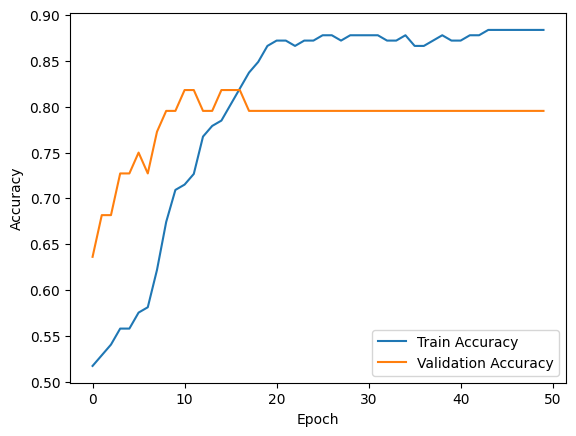

In [17]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


**Grafik menunjukkan peningkatan akurasi model selama proses pelatihan serta kestabilan antara data latih dan validasi.**

**Berdasarkan hasil pengujian, Artificial Neural Network mampu memberikan performa yang baik dalam memprediksi penyakit jantung dan menunjukkan hasil yang kompetitif dibandingkan model pembanding.**

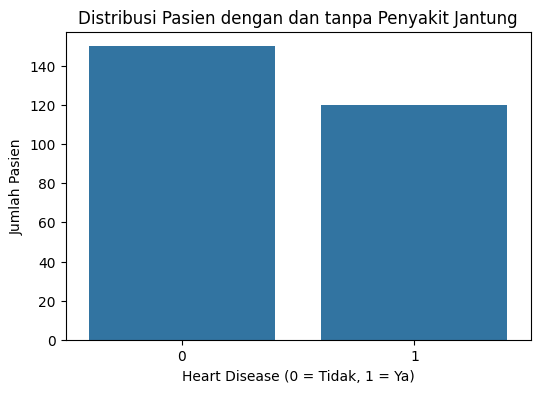

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="Heart_Disease", data=df)
plt.title("Distribusi Pasien dengan dan tanpa Penyakit Jantung")
plt.xlabel("Heart Disease (0 = Tidak, 1 = Ya)")
plt.ylabel("Jumlah Pasien")
plt.show()


**Visualisasi ini menunjukkan distribusi pasien yang mengalami penyakit jantung dan yang tidak. Distribusi kelas yang relatif seimbang membantu model dalam proses pembelajaran tanpa bias terhadap salah satu kelas.**

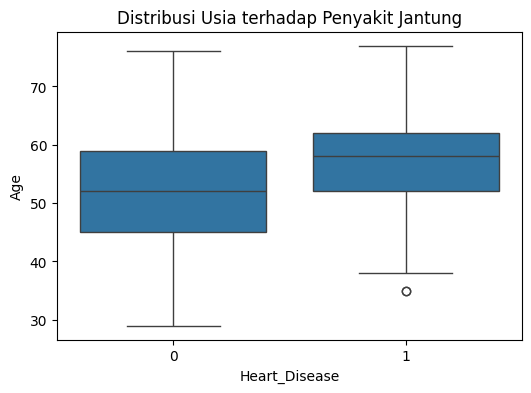

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Heart_Disease", y="Age", data=df)
plt.title("Distribusi Usia terhadap Penyakit Jantung")
plt.show()


**Boxplot menunjukkan bahwa pasien dengan penyakit jantung cenderung berada pada kelompok usia yang lebih tinggi dibandingkan pasien tanpa penyakit jantung.**

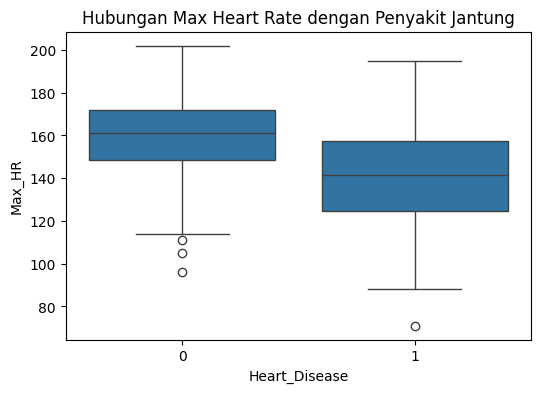

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Heart_Disease", y="Max_HR", data=df)
plt.title("Hubungan Max Heart Rate dengan Penyakit Jantung")
plt.show()


**Hasil visualisasi menunjukkan bahwa pasien dengan penyakit jantung cenderung memiliki nilai detak jantung maksimum yang lebih rendah.**

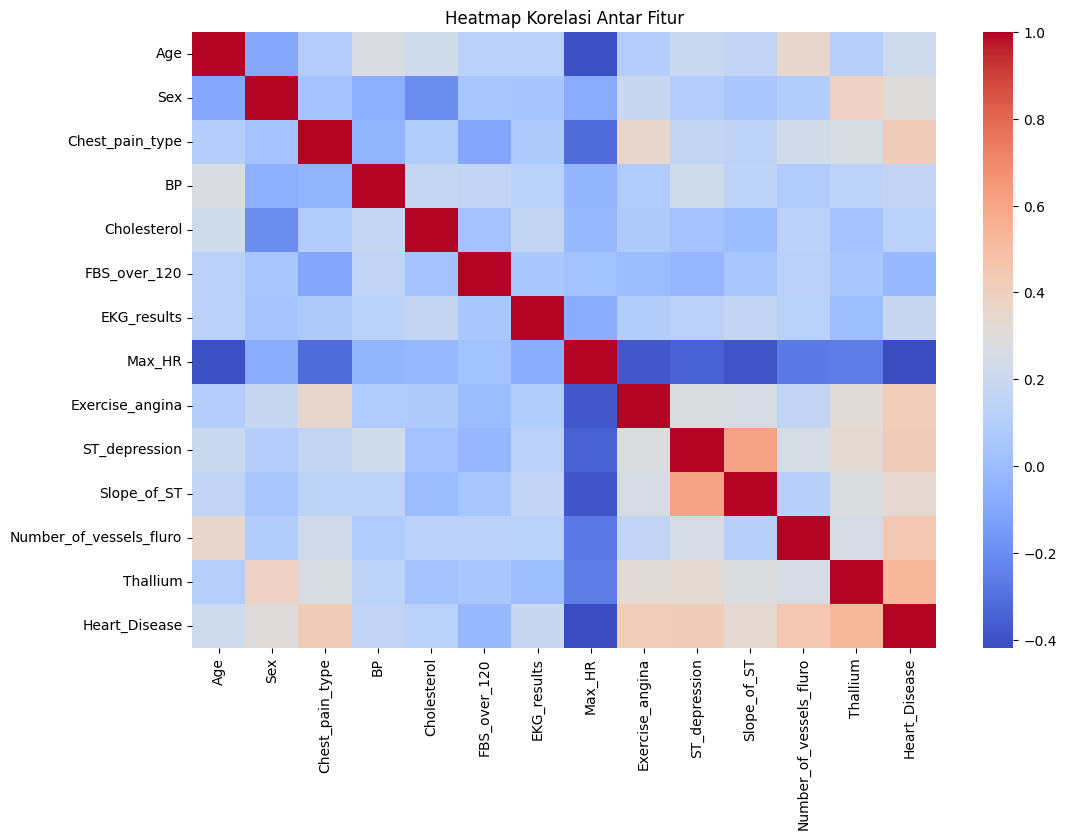

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()


**Heatmap korelasi digunakan untuk mengidentifikasi hubungan antar fitur. Beberapa fitur menunjukkan korelasi terhadap variabel target, yang mengindikasikan relevansi fitur tersebut dalam prediksi penyakit jantung.**

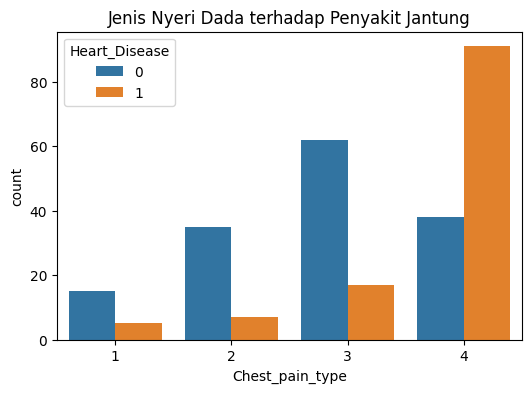

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x="Chest_pain_type", hue="Heart_Disease", data=df)
plt.title("Jenis Nyeri Dada terhadap Penyakit Jantung")
plt.show()


**Visualisasi ini menunjukkan bahwa jenis nyeri dada tertentu memiliki hubungan yang lebih kuat dengan keberadaan penyakit jantung.**

**Berdasarkan hasil Exploratory Data Analysis, diketahui bahwa beberapa faktor seperti usia, detak jantung maksimum, dan jenis nyeri dada memiliki hubungan dengan keberadaan penyakit jantung. Dataset juga memiliki distribusi kelas yang relatif seimbang serta tidak memiliki nilai kosong, sehingga layak digunakan untuk proses pemodelan.**

**FEATURE ENGINEERING**
Sudah dilakukan pada tahap sebelumnya menggunakan StandardScaler
Feature engineering dilakukan dengan normalisasi data menggunakan StandardScaler agar seluruh fitur memiliki skala yang seragam dan dapat meningkatkan performa Artificial Neural Network.

**TRAINING & PERBANDINGAN MODEL**
Logistic Regression digunakan sebagai baseline model, sedangkan Artificial Neural Network digunakan sebagai model utama. ANN memiliki kemampuan untuk menangkap hubungan non-linear antar fitur sehingga diharapkan memberikan performa yang lebih baik.

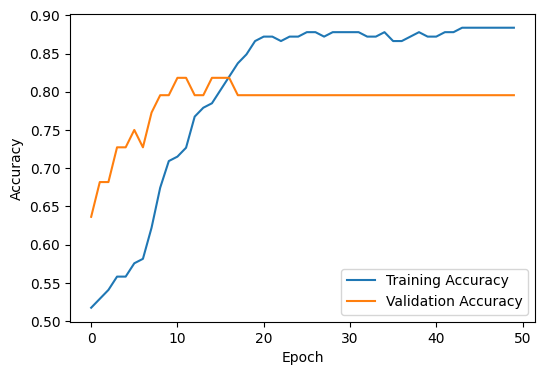

In [24]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


**EVALUASI & ANALISIS**
Grafik menunjukkan peningkatan akurasi selama proses pelatihan serta kestabilan antara data latih dan data validasi, yang menandakan bahwa model tidak mengalami overfitting secara signifikan.

# Kesimpulan
Berdasarkan hasil pengujian, Artificial Neural Network menunjukkan performa yang baik dalam memprediksi penyakit jantung. Dibandingkan dengan Logistic Regression, ANN mampu memberikan akurasi yang lebih tinggi karena kemampuannya dalam memodelkan hubungan non-linear antar fitur medis.